# Evaluating the RDA DMP JSON outputs

Three models turned DMP PDFs into RDA maDMP JSON. This notebook scores each model's
JSON against the manually written reference JSON for the same sample, the same way
the manual workbook does — but computed, so every verdict can be traced to a rule.

**The three verdicts, exactly as in the workbook**

| Verdict | Meaning |
|---|---|
| **Correct** | the model wrote a field, and its value matches the reference — or both are empty |
| **Hallucinated** | the model wrote a field whose value is wrong, invented (the reference has nothing there), or empty where the reference has a value |
| **Missed** | a reference field the model never produced correctly |

Every field the model output gets one of the first two; `Correct + Hallucinated` is
therefore exactly "fields the model output". `Missed` is counted on the reference side.

**The metrics, with the numbers from the workbook's llama3.1 sheet.** 17 fields output,
14 correct, 3 hallucinated, 115 fields in the reference:

- precision = correct / fields output = 14 / 17 = **0.82** — of what the model said, how much was right
- recall = correct / fields in reference = 14 / 115 = **0.12** — of what the document contains, how much was found
- F1 = 2 × 0.82 × 0.12 / (0.82 + 0.12) = **0.21** — the balance of the two

**How a value is judged to match** — the workbook's leniencies, written down:

| Kind of field | Rule | Example that passes |
|---|---|---|
| identifiers, emails, URLs | exact, after dropping `https://`, `www.`, `doi.org/`, case and trailing `/` | `https://doi.org/10.21966/1.566666` = `10.21966/1.566666` |
| licences | exact, after mapping to a short form | `https://creativecommons.org/licenses/by/4.0/` = `CC BY 4.0` |
| dates | same calendar day | `2015-05-12T00:00:00Z` = `2015-05-12` |
| controlled values (`type`, `data_access`, yes/no fields, `language`, roles) | exact, case-insensitive | `DOI` = `doi` |
| free text (titles, names, descriptions) | at least 75% of the model's words appear in the reference value — the same containment rule the project's Path A / Path B scoring uses | `Hakai JSP Time Series` ≈ `Hakai Institute Juvenile Salmon Program Time Series` |

Saying *less* than the reference can still match; saying *more* cannot:
"… Time Series **Data Management Plan**" fails because only 7 of its 10 words are in the
reference. Datasets, contributors and other list items are paired with the reference
item of the same title or name when there is one, and by position otherwise — again
what the workbook did by hand.


In [1]:
import json
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

if Path.cwd().name == "notebooks":
    import os
    os.chdir(Path.cwd().parent)

# The project's own containment rule, so this evaluation and Path A / B agree.
from dmpbridge.evaluation.evaluate import tokenize, containment, CONTAINMENT_THRESHOLD

# ── Where things are ─────────────────────────────────────────────────────────
RDA_DIR   = Path("data/output/rda")
MODELS    = ["llama3.1-8b", "gemma4-e4b", "llama3.3-70b"]      # as in the file names
REFERENCE = "RDA_DMP_sample{n}_manual_annotation.json"           # one per sample
OUTPUT    = "sample{n}.rda.{model}.json"                         # one per sample and model
WORKBOOK  = RDA_DIR / "RDA_simple14_ simple prompt and full RDA.xlsx"   # manual verdicts, for the agreement check
RESULTS   = RDA_DIR / "evaluation_results.xlsx"

# ── Judging rules ────────────────────────────────────────────────────────────
EMPTY       = {"", "null", "none", "n/a", "na", "unknown value"}   # what counts as "nothing"
THRESHOLD   = CONTAINMENT_THRESHOLD                                 # 0.75: share of the model's words that must be in the reference
ONE_OR_MANY = {"contact_id", "contributor_id", "creator_id", "metadata_standard_id"}  # schema allows one object or a list

ID_FIELDS   = {"identifier", "mbox", "url", "access_url", "download_url", "scheme_uri", "license_ref"}
DATE_FIELDS = {"created", "modified", "issued", "start", "end", "start_date", "available_until"}
ENUM_FIELDS = {"type", "data_access", "personal_data", "sensitive_data", "ethical_issues_exist",
               "language", "relation_type", "resource_type", "funding_status", "role",
               "certified_with", "geo_location", "pid_system", "currency_code", "is_reused"}

# Charts: repo palette. Verdicts use the validated blue/red pair plus a neutral gray for
# "missed" (deliberately colourless: it means nothing was extracted). Models keep the
# slot order every other notebook in this repo uses, so a model's colour never changes.
VERDICT_COLOUR = {"Correct": "#2a78d6", "Hallucinated": "#e34948", "Missed": "#898781"}
MODEL_COLOUR   = dict(zip(MODELS, ["#2a78d6", "#eb6834", "#1baf7a"]))
INK, MUTED, SURFACE, GRID = "#0b0b0b", "#52514e", "#fcfcfb", "#e6e6e2"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "text.color": INK, "axes.labelcolor": MUTED,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.edgecolor": "#d8d8d4", "axes.titlecolor": INK,
    "font.size": 10, "axes.titlesize": 11.5, "axes.titleweight": "bold",
    "axes.grid": False, "legend.frameon": False,
})
pd.set_option("display.max_colwidth", 70)
pd.set_option("display.width", 200)

samples = sorted(int(m.group(1)) for p in RDA_DIR.glob("RDA_DMP_sample*_manual_annotation.json")
                 if (m := re.search(r"sample(\d+)", p.name)))
print("samples with a reference:", samples)
for n in samples:
    have = [m for m in MODELS if (RDA_DIR / OUTPUT.format(n=n, model=m)).exists()]
    print(f"  sample{n}: outputs from {', '.join(have) or 'no model'}")


samples with a reference: [14]
  sample14: outputs from llama3.1-8b, gemma4-e4b, llama3.3-70b


## 1. Flatten the JSON into fields

A nested document becomes a list of `path = value` pairs, e.g.
`dmp.dataset[2].title = "Otolith Microchemistry from juvenile sockeye"`. Two details:

- Where the schema allows *either one object or a list* (`contact_id`, `contributor_id`,
  `creator_id`, `metadata_standard_id`), a single object is treated as a one-item list, so
  `contact_id.identifier` and `contact_id[0].identifier` are the same field.
- A reference field only counts if it has a value; an empty model field still counts as
  "output", because the model chose to write it (the workbook counts them the same way).


In [2]:
def is_empty(v):
    return v is None or v == [] or v == {} or (isinstance(v, str) and v.strip().lower() in EMPTY)


def canonical(node):
    """Wrap a single object into a one-item list wherever the schema allows either."""
    if isinstance(node, dict):
        out = {}
        for k, v in node.items():
            v = canonical(v)
            if k in ONE_OR_MANY and isinstance(v, dict):
                v = [v]
            out[k] = v
        return out
    if isinstance(node, list):
        return [canonical(v) for v in node]
    return node


def flatten(node, path=""):
    """Every leaf of a document as (path, value)."""
    if isinstance(node, dict):
        for k, v in node.items():
            yield from flatten(v, f"{path}.{k}" if path else k)
    elif isinstance(node, list):
        for i, v in enumerate(node):
            yield from flatten(v, f"{path}[{i}]")
    else:
        yield path, node


def load(path):
    return canonical(json.loads(Path(path).read_text(encoding="utf-8")))


# Quick look at the reference for the first sample
ref = load(RDA_DIR / REFERENCE.format(n=samples[0]))
ref_fields = {p: v for p, v in flatten(ref) if not is_empty(v)}
print(f"sample{samples[0]} reference: {len(ref_fields)} fields with a value "
      f"(of {sum(1 for _ in flatten(ref))} leaves in the file)")
for p, v in list(ref_fields.items())[:8]:
    print(f"  {p:48} {json.dumps(v, ensure_ascii=False)[:60]}")
print("  ...")


sample14 reference: 115 fields with a value (of 345 leaves in the file)
  dmp.title                                        "Hakai Institute Juvenile Salmon Program Time Series"
  dmp.dmp_id.identifier                            "https://doi.org/10.48321/D1CW23"
  dmp.modified                                     "2024-06-11T00:00:00Z"
  dmp.ethical_issues_exist                         "no"
  dmp.contact.name                                 "Brett Johnson"
  dmp.contact.affiliation[0].name                  "Hakai Institute"
  dmp.contact.contact_id[0].identifier             "0000-0001-9317-0364"
  dmp.contact.contact_id[0].type                   "orcid"
  ...


## 2. Line up list items

A model may put the datasets in a different order from the reference, or find only some
of them. Before comparing values, each list item in the model output is paired with a
reference item: by **matching title / name / identifier** when one exists, otherwise by
**position**. The model's paths are then rewritten to use the reference's indices, so
`dataset[1]` in the model can be scored against `dataset[2]` in the reference when that
is the dataset it actually describes.


In [3]:
KEY_FIELDS = ("title", "name", "identifier", "license_ref")


def item_key(item):
    """The value that identifies a list item, if it has one."""
    if isinstance(item, dict):
        for k in KEY_FIELDS:
            if not is_empty(item.get(k)):
                return norm_text(item[k])
        return None
    return norm_text(item) if not is_empty(item) else None


def norm_text(v):
    return re.sub(r"\s+", " ", str(v)).strip().lower()


def pair_items(model_list, ref_list):
    """model index -> reference index. Exact key matches first, then position."""
    ref_keys = {item_key(r): j for j, r in enumerate(ref_list)}
    ref_keys.pop(None, None)
    mapping, taken = {}, set()
    for i, m in enumerate(model_list):                       # pass 1: same title / name
        j = ref_keys.get(item_key(m))
        if j is not None and j not in taken:
            mapping[i], taken = j, taken | {j}
    for i, m in enumerate(model_list):                       # pass 2: same position, else a free slot
        if i in mapping:
            continue
        j = i if i not in taken else next((k for k in range(len(ref_list)) if k not in taken), None)
        if j is None:                                        # more items than the reference has
            j = len(ref_list) + len([x for x in mapping.values() if x >= len(ref_list)])
        mapping[i], taken = j, taken | {j}
    return mapping


def flatten_aligned(model, ref, path="", mpath=""):
    """Flatten the model document using the reference's list indices.
    Yields (reference-aligned path, the model's own path, value)."""
    if isinstance(model, dict):
        for k, v in model.items():
            r = ref.get(k) if isinstance(ref, dict) else None
            yield from flatten_aligned(v, r, f"{path}.{k}" if path else k, f"{mpath}.{k}" if mpath else k)
    elif isinstance(model, list):
        ref_list = ref if isinstance(ref, list) else []
        mapping = pair_items(model, ref_list)
        for i, v in enumerate(model):
            j = mapping[i]
            yield from flatten_aligned(v, ref_list[j] if j < len(ref_list) else None, f"{path}[{j}]", f"{mpath}[{i}]")
    else:
        yield path, mpath, model


# Example: which reference dataset each model dataset was paired with, first sample
for m in MODELS:
    p = RDA_DIR / OUTPUT.format(n=samples[0], model=m)
    if not p.exists():
        continue
    out = load(p)
    ds_model = out.get("dmp", {}).get("dataset", [])
    ds_ref = ref.get("dmp", {}).get("dataset", [])
    pairs = pair_items(ds_model, ds_ref)
    print(f"{m}:")
    for i, j in pairs.items():
        mt = ds_model[i].get("title") if isinstance(ds_model[i], dict) else ds_model[i]
        rt = ds_ref[j].get("title") if j < len(ds_ref) else "(no reference item)"
        print(f"   model dataset[{i}] {str(mt)[:38]!r:42} -> reference dataset[{j}] {str(rt)[:38]!r}")


llama3.1-8b:
   model dataset[0] 'Hakai Institute Juvenile Salmon Progra'   -> reference dataset[0] 'Hakai Institute Juvenile Salmon Progra'
gemma4-e4b:
   model dataset[0] 'Hakai JSP Time Series'                    -> reference dataset[0] 'Hakai Institute Juvenile Salmon Progra'
   model dataset[1] 'Juvenile Salmon Program Time Series'      -> reference dataset[1] 'Fatty acids from juvenile salmon'
llama3.3-70b:
   model dataset[0] 'Hakai Institute Juvenile Salmon Progra'   -> reference dataset[0] 'Hakai Institute Juvenile Salmon Progra'
   model dataset[1] 'Otolith Microchemistry from juvenile s'   -> reference dataset[2] 'Otolith Microchemistry from juvenile s'


## 3. Judge each field

`verdict(path, model_value, reference_value)` returns **Correct** or **Hallucinated** and
a one-line reason. The rule used depends on the kind of field (see the table at the top).


In [4]:
def field_kind(path):
    last = re.sub(r"\[\d+\]$", "", path.split(".")[-1])
    if last in ID_FIELDS:   return "identifier"
    if last in DATE_FIELDS: return "date"
    if last in ENUM_FIELDS: return "controlled"
    return "text"


LICENCE = [(re.compile(r"creativecommons\.org/licenses/([a-z\-]+)/(\d\.\d)"), r"cc-\1-\2"),
           (re.compile(r"^cc[\s\-]+([a-z][a-z\-]*)[\s\-]+(\d\.\d)$"), r"cc-\1-\2")]


def norm_id(v):
    s = norm_text(v)
    s = re.sub(r"^https?://", "", s)
    s = re.sub(r"^(www\.|dx\.)?doi\.org/", "", s)
    s = re.sub(r"^www\.", "", s).rstrip("/")
    for pattern, repl in LICENCE:
        if pattern.search(s):
            return pattern.sub(repl, s)
    return s


def norm_date(v):
    s = norm_text(v)
    m = re.search(r"(\d{4})-(\d{2})-(\d{2})", s)
    return f"{m[1]}-{m[2]}-{m[3]}" if m else s


def verdict(path, mv, rv):
    """-> (verdict, reason)."""
    m_empty, r_empty = is_empty(mv), is_empty(rv)
    if m_empty and r_empty:
        return "Correct", "both empty"
    if m_empty:
        return "Hallucinated", "empty where the reference has a value"
    if r_empty:
        return "Hallucinated", "not in the reference"
    kind = field_kind(path)
    if kind == "identifier":
        ok, how = norm_id(mv) == norm_id(rv), "identifier differs"
    elif kind == "date":
        ok, how = norm_date(mv) == norm_date(rv), "different day"
    elif kind == "controlled":
        ok, how = norm_text(mv) == norm_text(rv), "different value"
    else:
        share = containment(tokenize(str(mv)), tokenize(str(rv)))
        ok, how = share >= THRESHOLD, f"only {share:.0%} of the model's words are in the reference"
    return ("Correct", "") if ok else ("Hallucinated", how)


# Sanity check against cases decided by hand in the workbook
checks = [
    ("dmp.dataset[0].title", "Hakai JSP Time Series", "Hakai Institute Juvenile Salmon Program Time Series", "Correct"),
    ("dmp.title", "Hakai Institute Juvenile Salmon Program Time Series Data Management Plan",
                  "Hakai Institute Juvenile Salmon Program Time Series", "Hallucinated"),
    ("dmp.dataset[0].distribution[0].license[0].license_ref", "https://creativecommons.org/licenses/by/4.0/", "CC BY 4.0", "Correct"),
    ("dmp.project[0].start", "2015-05-12T00:00:00Z", "2015-05-12", "Correct"),
    ("dmp.contact.mbox", "brett.johnson@hakai.org", None, "Hallucinated"),
    ("dmp.contact.mbox", "N/A", None, "Correct"),
    ("dmp.contact.name", "N/A", "Brett Johnson", "Hallucinated"),
    ("dmp.dataset[0].dataset_id.identifier", "https://doi.org/10.48321/D1CW23", "https://doi.org/10.21966/1.566666", "Hallucinated"),
]
for path, mv, rv, expected in checks:
    got, why = verdict(path, mv, rv)
    print(f"{'ok ' if got == expected else 'XX '} {got:13} {str(mv)[:42]!r:46} vs {str(rv)[:34]!r:38} {why}")


ok  Correct       'Hakai JSP Time Series'                        vs 'Hakai Institute Juvenile Salmon Pr'   
ok  Hallucinated  'Hakai Institute Juvenile Salmon Program Ti'   vs 'Hakai Institute Juvenile Salmon Pr'   only 70% of the model's words are in the reference
ok  Correct       'https://creativecommons.org/licenses/by/4.'   vs 'CC BY 4.0'                            
ok  Correct       '2015-05-12T00:00:00Z'                         vs '2015-05-12'                           
ok  Hallucinated  'brett.johnson@hakai.org'                      vs 'None'                                 not in the reference
ok  Correct       'N/A'                                          vs 'None'                                 both empty
ok  Hallucinated  'N/A'                                          vs 'Brett Johnson'                        empty where the reference has a value
ok  Hallucinated  'https://doi.org/10.48321/D1CW23'              vs 'https://doi.org/10.21966/1.566666'    identifier differs


## 4. Score every sample and model

One row per judged field. Missed reference fields are added as rows with no model value.


In [5]:
rows = []
for n in samples:
    ref = load(RDA_DIR / REFERENCE.format(n=n))
    ref_values = dict(flatten(ref))
    ref_fields = {p for p, v in ref_values.items() if not is_empty(v)}
    for m in MODELS:
        p = RDA_DIR / OUTPUT.format(n=n, model=m)
        if not p.exists():
            continue
        covered = set()
        for path, mpath, mv in flatten_aligned(load(p), ref):
            rv = ref_values.get(path)
            v, why = verdict(path, mv, rv)
            if v == "Correct" and path in ref_fields:
                covered.add(path)
            rows.append({"sample": n, "model": m, "field": path, "model field": mpath, "model value": mv,
                         "reference value": rv, "verdict": v, "reason": why})
        for path in sorted(ref_fields - covered):
            rows.append({"sample": n, "model": m, "field": path, "model field": None, "model value": None,
                         "reference value": ref_values[path], "verdict": "Missed", "reason": ""})

details = pd.DataFrame(rows)
print(f"{len(details)} judged rows across {len(samples)} sample(s) and {details['model'].nunique()} models")
details.groupby(["model", "verdict"]).size().unstack(fill_value=0)[["Correct", "Hallucinated", "Missed"]]


385 judged rows across 1 sample(s) and 3 models


verdict,Correct,Hallucinated,Missed
model,,,
gemma4-e4b,6,17,110
llama3.1-8b,9,8,106
llama3.3-70b,17,14,98


## 5. Metrics

Per model, over all samples (and per sample underneath). `fields in reference` counts
reference fields with a value; `fields output` counts every field the model wrote.


In [6]:
def metrics(df, n_ref):
    c = int((df["verdict"] == "Correct").sum())
    h = int((df["verdict"] == "Hallucinated").sum())
    miss = int((df["verdict"] == "Missed").sum())
    out = c + h
    found = n_ref - miss                               # reference fields the model got right
    precision = c / out if out else 0.0
    recall = found / n_ref if n_ref else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    total = c + h + miss
    return {"fields in reference": n_ref, "fields output": out, "correct": c, "hallucinated": h,
            "missed": miss, "precision": round(precision, 3), "recall": round(recall, 3),
            "f1": round(f1, 3), "correct %": round(c / total, 3), "hallucinated %": round(h / total, 3),
            "missed %": round(miss / total, 3)}


n_ref_total = {n: len({p for p, v in flatten(load(RDA_DIR / REFERENCE.format(n=n))) if not is_empty(v)})
               for n in samples}

summary = pd.DataFrame({m: metrics(details[details["model"] == m], sum(n_ref_total.values()))
                        for m in MODELS if m in set(details["model"])})
per_sample = pd.DataFrame(
    {(n, m): metrics(details[(details["model"] == m) & (details["sample"] == n)], n_ref_total[n])
     for n in samples for m in MODELS if ((details["model"] == m) & (details["sample"] == n)).any()})

print("All samples together:")
display(summary)
if len(samples) > 1:
    print("\nPer sample:")
    display(per_sample)


All samples together:


,llama3.1-8b,gemma4-e4b,llama3.3-70b
fields in reference,115.000,115.000,115.000
fields output,17.000,23.000,31.000
correct,9.000,6.000,17.000
hallucinated,8.000,17.000,14.000
missed,106.000,110.000,98.000
precision,0.529,0.261,0.548
recall,0.078,0.043,0.148
f1,0.136,0.075,0.233
correct %,0.073,0.045,0.132
hallucinated %,0.065,0.128,0.109


## 6. Detailed comparison, per model

The same columns as the workbook's per-model sheets — field, model value, reference value,
verdict — plus the reason the rule gave. Hallucinated rows first, so the problems are at the top.


In [7]:
ORDER = {"Hallucinated": 0, "Correct": 1, "Missed": 2}
for m in MODELS:
    d = details[details["model"] == m].copy()
    if d.empty:
        continue
    d["_o"] = d["verdict"].map(ORDER)
    d = d.sort_values(["sample", "_o", "field"]).drop(columns="_o")
    counts = d["verdict"].value_counts()
    print(f"\n{'=' * 100}\n{m}: {counts.get('Correct', 0)} correct, {counts.get('Hallucinated', 0)} hallucinated, "
          f"{counts.get('Missed', 0)} missed\n{'=' * 100}")
    display(d[d["verdict"] != "Missed"][["sample", "field", "model value", "reference value", "verdict", "reason"]]
            .reset_index(drop=True))



llama3.1-8b: 9 correct, 8 hallucinated, 106 missed


,sample,field,model value,reference value,verdict,reason
0,14,dmp.contact.mbox,brett.johnson@hakai.org,None,Hallucinated,not in the reference
1,14,dmp.created,2015-05-12T00:00:00Z,None,Hallucinated,not in the reference
2,14,dmp.dataset[0].dataset_id.identifier,https://doi.org/10.48321/D1CW23,https://doi.org/10.21966/1.566666,Hallucinated,identifier differs
3,14,dmp.dataset[0].personal_data,no,None,Hallucinated,not in the reference
4,14,dmp.dataset[0].sensitive_data,no,None,Hallucinated,not in the reference
5,14,dmp.dataset[0].type,dataset,None,Hallucinated,not in the reference
6,14,dmp.dmp_id.type,doi,None,Hallucinated,not in the reference
7,14,dmp.language,eng,None,Hallucinated,not in the reference
8,14,dmp.contact.contact_id[0].identifier,0000-0001-9317-0364,0000-0001-9317-0364,Correct,
9,14,dmp.contact.contact_id[0].type,orcid,orcid,Correct,



gemma4-e4b: 6 correct, 17 hallucinated, 110 missed


,sample,field,model value,reference value,verdict,reason
0,14,dmp.contact.contact_id[0].identifier,0000-0003-0644-4174,0000-0001-9317-0364,Hallucinated,identifier differs
1,14,dmp.contact.name,N/A,Brett Johnson,Hallucinated,empty where the reference has a value
2,14,dmp.created,2024-06-11T00:00:00Z,None,Hallucinated,not in the reference
3,14,dmp.dataset[0].dataset_id.identifier,www.github.com/hakaiinstitute/jsp-data,https://doi.org/10.21966/1.566666,Hallucinated,identifier differs
4,14,dmp.dataset[0].dataset_id.type,url,doi,Hallucinated,different value
5,14,dmp.dataset[0].personal_data,unknown,None,Hallucinated,not in the reference
6,14,dmp.dataset[0].sensitive_data,unknown,None,Hallucinated,not in the reference
7,14,dmp.dataset[0].type,raw data,None,Hallucinated,not in the reference
8,14,dmp.dataset[1].dataset_id.identifier,https://doi.org/10.21966/1.566666,None,Hallucinated,not in the reference
9,14,dmp.dataset[1].dataset_id.type,image,None,Hallucinated,not in the reference



llama3.3-70b: 17 correct, 14 hallucinated, 98 missed


,sample,field,model value,reference value,verdict,reason
0,14,dmp.contact.affiliation[0].affiliation_id.identifier,https://www.hakai.org/,None,Hallucinated,not in the reference
1,14,dmp.contact.affiliation[0].affiliation_id.type,url,None,Hallucinated,not in the reference
2,14,dmp.contact.mbox,brett.johnson@hakai.org,None,Hallucinated,not in the reference
3,14,dmp.created,2015-05-12T00:00:00Z,None,Hallucinated,not in the reference
4,14,dmp.dataset[0].description,The Hakai Institute Juvenile Salmon program is an ongoing initiati...,The core of the Hakai JSP are the observations made at sea during ...,Hallucinated,only 21% of the model's words are in the reference
5,14,dmp.dataset[0].distribution[0].description,Core observations made in the field and from lab dissections condu...,None,Hallucinated,not in the reference
6,14,dmp.dataset[0].distribution[0].license[0].start_date,2020-01-01,None,Hallucinated,not in the reference
7,14,dmp.dataset[0].distribution[0].title,Hakai JSP Time Series,None,Hallucinated,not in the reference
8,14,dmp.dataset[0].personal_data,no,None,Hallucinated,not in the reference
9,14,dmp.dataset[0].sensitive_data,no,None,Hallucinated,not in the reference


## 7. Where the misses are

Missed fields grouped by the part of the schema they belong to — this says *what kind* of
information each model fails to extract, which the overall count hides.


In [8]:
def section(path):
    parts = path.split(".")
    return re.sub(r"\[\d+\]", "", parts[1]) if parts[0] == "dmp" and len(parts) > 1 else parts[0]


ref_counts = pd.Series([section(p) for n in samples for p, v in flatten(load(RDA_DIR / REFERENCE.format(n=n)))
                        if not is_empty(v)]).value_counts()
missed = details[details["verdict"] == "Missed"].copy()
missed["section"] = missed["field"].map(section)
by_section = (missed.groupby(["section", "model"]).size().unstack(fill_value=0)
              .reindex(ref_counts.index, fill_value=0))
by_section.insert(0, "reference fields", ref_counts)
by_section


model,reference fields,gemma4-e4b,llama3.1-8b,llama3.3-70b
dataset,93,92,91,84
contributor,9,9,9,9
contact,4,3,1,0
project,4,4,4,4
title,1,0,0,0
ethical_issues_exist,1,1,0,0
modified,1,0,0,0
dmp_id,1,0,0,0
related_identifier,1,1,1,1


## 8. Charts

Left: the share of each model's total that is correct, hallucinated or missed — the
workbook's "slide bar". Right: precision, recall and F1 per model.


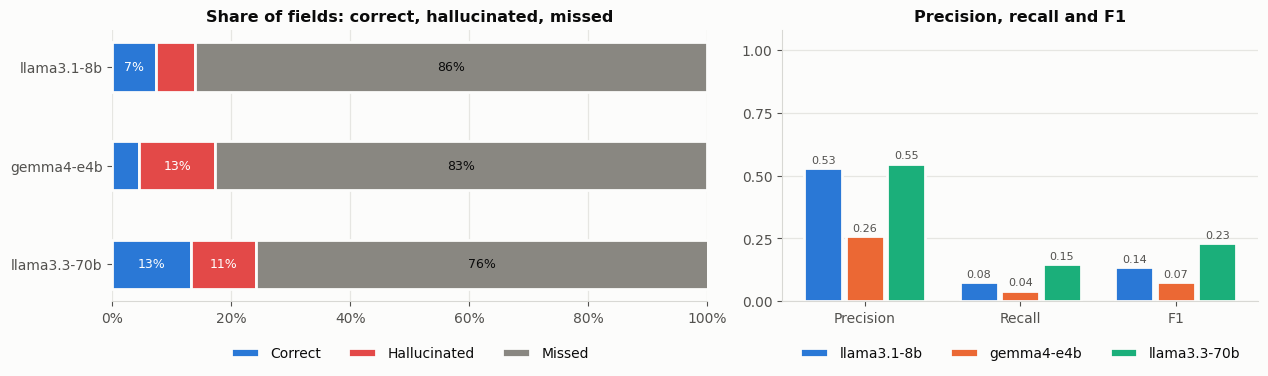

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 3.9), gridspec_kw={"width_ratios": [1.25, 1]})

# ── Correct / Hallucinated / Missed shares, one bar per model ────────────────
models = list(summary.columns)
left = [0.0] * len(models)
for v in ("Correct", "Hallucinated", "Missed"):
    vals = [summary.loc[f"{v.lower()} %", m] for m in models]
    bars = ax1.barh(models, vals, left=left, height=0.5, color=VERDICT_COLOUR[v],
                    edgecolor=SURFACE, linewidth=2, label=v)
    for bar, val in zip(bars, vals):
        if val >= 0.07:                                       # label only where it fits
            ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_y() + bar.get_height() / 2,
                     f"{val:.0%}", ha="center", va="center", fontsize=9,
                     color="white" if v != "Missed" else INK)
    left = [l + x for l, x in zip(left, vals)]
ax1.set_xlim(0, 1)
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax1.invert_yaxis()
ax1.set_title("Share of fields: correct, hallucinated, missed")
ax1.grid(axis="x", color=GRID, linewidth=0.9)
ax1.set_axisbelow(True)
ax1.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.12))
for side in ("top", "right", "left"):
    ax1.spines[side].set_visible(False)

# ── Precision / recall / F1 per model ────────────────────────────────────────
metrics_shown = ["precision", "recall", "f1"]
x = range(len(metrics_shown))
w = 0.8 / len(models)
for k, m in enumerate(models):
    vals = [summary.loc[mt, m] for mt in metrics_shown]
    bars = ax2.bar([i + (k - (len(models) - 1) / 2) * w for i in x], vals, width=w * 0.92,
                   color=MODEL_COLOUR[m], edgecolor=SURFACE, linewidth=2, label=m)
    ax2.bar_label(bars, fmt="%.2f", padding=2, fontsize=8, color=MUTED)
ax2.set_xticks(list(x))
ax2.set_xticklabels(["Precision", "Recall", "F1"])
ax2.set_ylim(0, 1.08)
ax2.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax2.set_title("Precision, recall and F1")
ax2.grid(axis="y", color=GRID, linewidth=0.9)
ax2.set_axisbelow(True)
ax2.legend(ncol=len(models), loc="upper center", bbox_to_anchor=(0.5, -0.12))
for side in ("top", "right"):
    ax2.spines[side].set_visible(False)

plt.tight_layout()
fig.savefig(RDA_DIR / "evaluation_charts.png", dpi=200, bbox_inches="tight", facecolor=SURFACE)
plt.show()


## 9. Save the results

An Excel workbook laid out like the manual one: a `summary` sheet, one sheet per model with
the detailed verdicts, and `details` with every row.


In [10]:
with pd.ExcelWriter(RESULTS) as xw:
    summary.to_excel(xw, sheet_name="summary")
    for m in MODELS:
        d = details[details["model"] == m]
        if not d.empty:
            d.drop(columns="model").to_excel(xw, sheet_name=m[:31], index=False)
    details.to_excel(xw, sheet_name="details", index=False)
print(f"saved -> {RESULTS}")
print(f"saved -> {RDA_DIR / 'evaluation_charts.png'}")


saved -> data\output\rda\evaluation_results.xlsx
saved -> data\output\rda\evaluation_charts.png


## 10. Agreement with the manual workbook

Does the automated verdict match the one made by hand? For every field in the workbook's
per-model sheets, the two verdicts are compared, and each disagreement is explained as one
of three things: the reference JSON is empty where the workbook's ground truth has a value
(fix the reference), the workbook judged an older model output than the file now on disk
(re-check the workbook), or the rule genuinely disagrees with the hand judgement (adjust
the rule, or the judgement). Either way it is visible.


In [11]:
def sheet_path(p):
    """Workbook paths sometimes omit [0] on one-or-many fields; add it."""
    p = str(p).strip()
    for k in ONE_OR_MANY:
        p = re.sub(rf"\.{k}\.", f".{k}[0].", p)
    return p


if WORKBOOK.exists():
    xl = pd.ExcelFile(WORKBOOK)
    reports = []
    for m in MODELS:
        sheet = next((s for s in xl.sheet_names if m in s), None)
        if sheet is None:
            continue
        manual = xl.parse(sheet)
        manual = manual[manual["Field"].notna()].copy()
        manual["field"] = manual["Field"].map(sheet_path)
        n = int(re.search(r"sample(\d+)", sheet).group(1))
        auto = details[(details["model"] == m) & (details["sample"] == n) & (details["verdict"] != "Missed")]
        joined = manual.merge(auto[["model field", "field", "model value", "verdict", "reason"]]
                              .rename(columns={"model field": "field", "field": "scored as"}),
                              on="field", how="left", suffixes=(" (manual)", " (auto)"))
        joined = joined.rename(columns={"Verdict": "manual verdict", "verdict": "auto verdict"})
        ref_now = dict(flatten(load(RDA_DIR / REFERENCE.format(n=n))))
        joined["reference JSON"] = joined["scored as"].map(ref_now)

        def explain(r):
            """Why a hand verdict and the rule's verdict differ."""
            if r["manual verdict"] == r["auto verdict"]:
                return ""
            if is_empty(r["reference JSON"]) and not is_empty(r["Ground truth"]):
                return "reference JSON is empty here; the workbook's ground truth is not"
            sheet_value = "" if pd.isna(r["Value"]) else str(r["Value"])
            if norm_text(sheet_value) != norm_text("" if r["model value"] is None else r["model value"]):
                return "the workbook judged a different model value than the file on disk"
            return "the rule disagrees with the hand judgement"

        joined["why they differ"] = joined.apply(explain, axis=1)
        agree = (joined["manual verdict"] == joined["auto verdict"]).sum()
        reports.append((m, agree, len(joined)))
        diff = joined[joined["manual verdict"] != joined["auto verdict"]]
        print(f"\n{m}: {agree} of {len(joined)} verdicts agree with the workbook")
        if not diff.empty:
            display(diff[["field", "Value", "model value", "Ground truth", "reference JSON",
                          "manual verdict", "auto verdict", "why they differ"]].reset_index(drop=True))
            print(diff["why they differ"].value_counts().to_string())
    print("\nOverall:", ", ".join(f"{m} {a}/{t}" for m, a, t in reports))
else:
    print("no manual workbook found at", WORKBOOK)



llama3.1-8b: 10 of 17 verdicts agree with the workbook


,field,Value,model value,Ground truth,reference JSON,manual verdict,auto verdict,why they differ
0,dmp.created,2015-05-12T00:00:00Z,2015-05-12T00:00:00Z,2015-05-12T00:00:00Z,None,Correct,Hallucinated,reference JSON is empty here; the workbook's ground truth is not
1,dmp.dataset[0].personal_data,no,no,no,None,Correct,Hallucinated,reference JSON is empty here; the workbook's ground truth is not
2,dmp.dataset[0].sensitive_data,no,no,no,None,Correct,Hallucinated,reference JSON is empty here; the workbook's ground truth is not
3,dmp.dataset[0].type,dataset,dataset,dataset,None,Correct,Hallucinated,reference JSON is empty here; the workbook's ground truth is not
4,dmp.dmp_id.type,doi,doi,doi,None,Correct,Hallucinated,reference JSON is empty here; the workbook's ground truth is not
5,dmp.language,eng,eng,eng,None,Correct,Hallucinated,reference JSON is empty here; the workbook's ground truth is not
6,dmp.title,Hakai Institute Juvenile Salmon Program Time Series Data Managemen...,Hakai Institute Juvenile Salmon Program Time Series,Hakai Institute Juvenile Salmon Program Time Series,Hakai Institute Juvenile Salmon Program Time Series,Hallucinated,Correct,the workbook judged a different model value than the file on disk


why they differ
reference JSON is empty here; the workbook's ground truth is not     6
the workbook judged a different model value than the file on disk    1

gemma4-e4b: 21 of 23 verdicts agree with the workbook


,field,Value,model value,Ground truth,reference JSON,manual verdict,auto verdict,why they differ
0,dmp.dmp_id.type,doi,doi,doi,None,Correct,Hallucinated,reference JSON is empty here; the workbook's ground truth is not
1,dmp.language,eng,eng,eng,None,Correct,Hallucinated,reference JSON is empty here; the workbook's ground truth is not


why they differ
reference JSON is empty here; the workbook's ground truth is not    2

llama3.3-70b: 25 of 31 verdicts agree with the workbook


,field,Value,model value,Ground truth,reference JSON,manual verdict,auto verdict,why they differ
0,dmp.created,2015-05-12T00:00:00Z,2015-05-12T00:00:00Z,2015-05-12T00:00:00Z,None,Correct,Hallucinated,reference JSON is empty here; the workbook's ground truth is not
1,dmp.dataset[0].personal_data,no,no,no,None,Correct,Hallucinated,reference JSON is empty here; the workbook's ground truth is not
2,dmp.dataset[0].sensitive_data,no,no,no,None,Correct,Hallucinated,reference JSON is empty here; the workbook's ground truth is not
3,dmp.dataset[0].distribution[0].title,Hakai JSP Time Series,Hakai JSP Time Series,Hakai JSP Time Series,None,Correct,Hallucinated,reference JSON is empty here; the workbook's ground truth is not
4,dmp.dmp_id.type,doi,doi,doi,None,Correct,Hallucinated,reference JSON is empty here; the workbook's ground truth is not
5,dmp.language,eng,eng,eng,None,Correct,Hallucinated,reference JSON is empty here; the workbook's ground truth is not


why they differ
reference JSON is empty here; the workbook's ground truth is not    6

Overall: llama3.1-8b 10/17, gemma4-e4b 21/23, llama3.3-70b 25/31
